
Informetion Gain:
X = 0.0
Y = 1.0
Z = 0.0

Actual Classes:
['I', 'I', 'II', 'II']

Predicted Classes
['I', 'I', 'II', 'II']


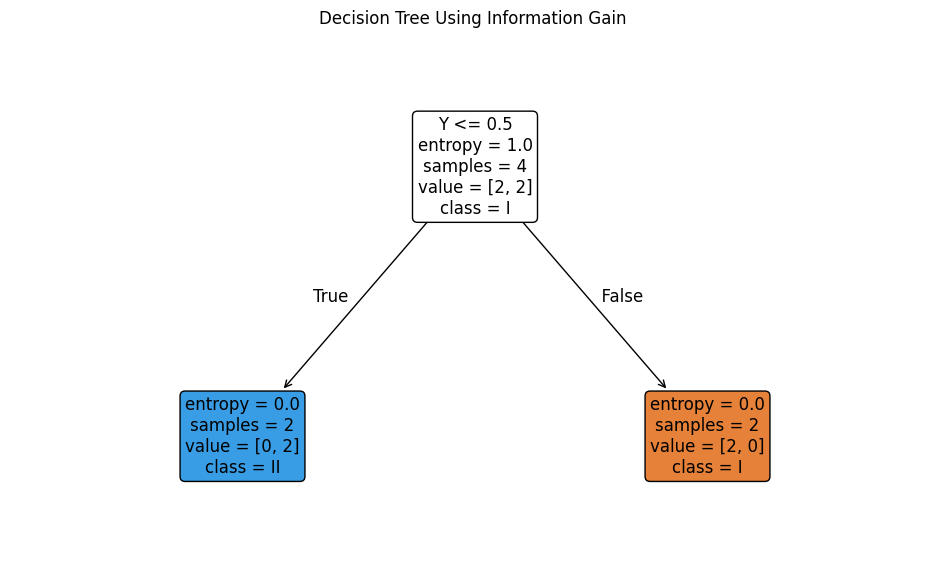

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier,plot_tree
data = {
    'X' : [1,1,0,1],
    'Y' : [1,1,0,0],
    'Z' : [1,0,1,0],
    'class' : ['I','I','II','II']
}
df=pd.DataFrame(data)
print
X=df[['X','Y','Z']]
Y=df['class']
model = DecisionTreeClassifier(
    criterion='entropy',
    random_state = 42
)
model.fit(X,Y)
print("\nInformetion Gain:")
for feature, importance in zip (X.columns, model.feature_importances_):
    print (feature, "=", round(importance, 4))
y_pred = model.predict(X)
print("\nActual Classes:")
print(list(Y))
print("\nPredicted Classes")
print(list(y_pred))
plt.figure(figsize=(12,7))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=model.classes_,
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title("Decision Tree Using Information Gain ")
plt.show()



<>:21: SyntaxWarning: invalid escape sequence '\D'
<>:24: SyntaxWarning: invalid escape sequence '\S'
<>:27: SyntaxWarning: invalid escape sequence '\C'
<>:45: SyntaxWarning: invalid escape sequence '\T'
<>:21: SyntaxWarning: invalid escape sequence '\D'
<>:24: SyntaxWarning: invalid escape sequence '\S'
<>:27: SyntaxWarning: invalid escape sequence '\C'
<>:45: SyntaxWarning: invalid escape sequence '\T'
/tmp/ipykernel_58/2095145958.py:21: SyntaxWarning: invalid escape sequence '\D'
  print("\Dataset Information:")
/tmp/ipykernel_58/2095145958.py:24: SyntaxWarning: invalid escape sequence '\S'
  print("\Statistical Description:")
/tmp/ipykernel_58/2095145958.py:27: SyntaxWarning: invalid escape sequence '\C'
  print("\Class Distribution:")
/tmp/ipykernel_58/2095145958.py:45: SyntaxWarning: invalid escape sequence '\T'
  print("\Testing Samples:", X_test.shape[0])


IRIS DATASET
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Dataset Shape:
(150, 6)

Column Names:
Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')
\Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm 

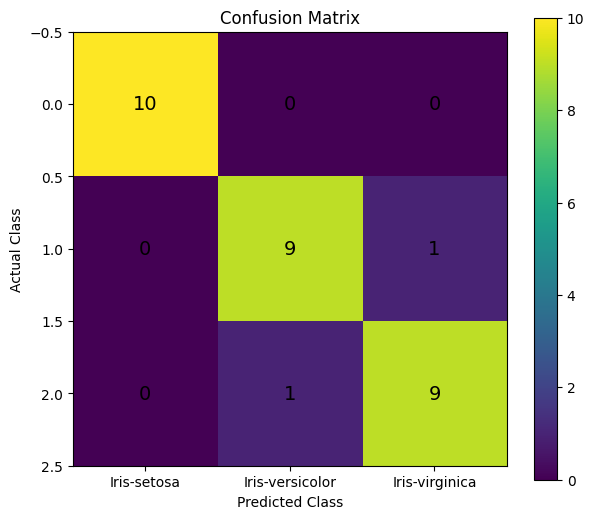


FEATURE IMPORTANCE
SepalLengthCm = 0.0066
SepalWidthCm = 0.0146
PetalLengthCm = 0.672
PetalWidthCm = 0.3068


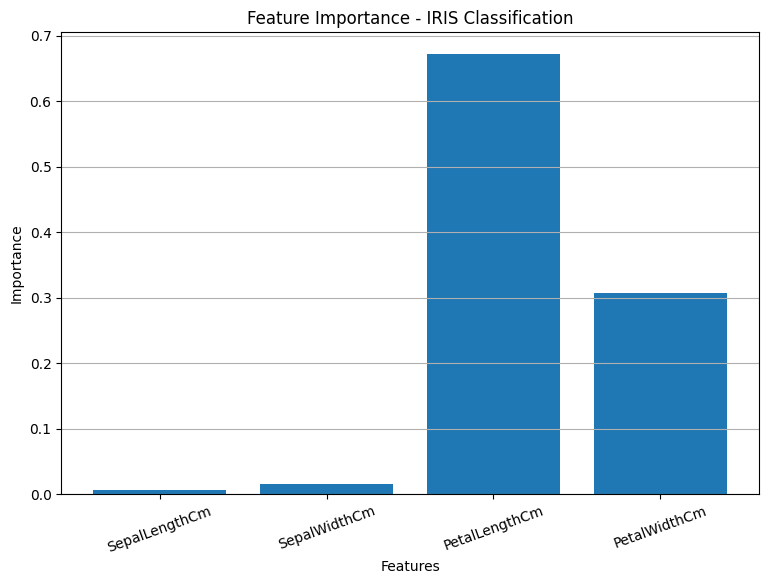

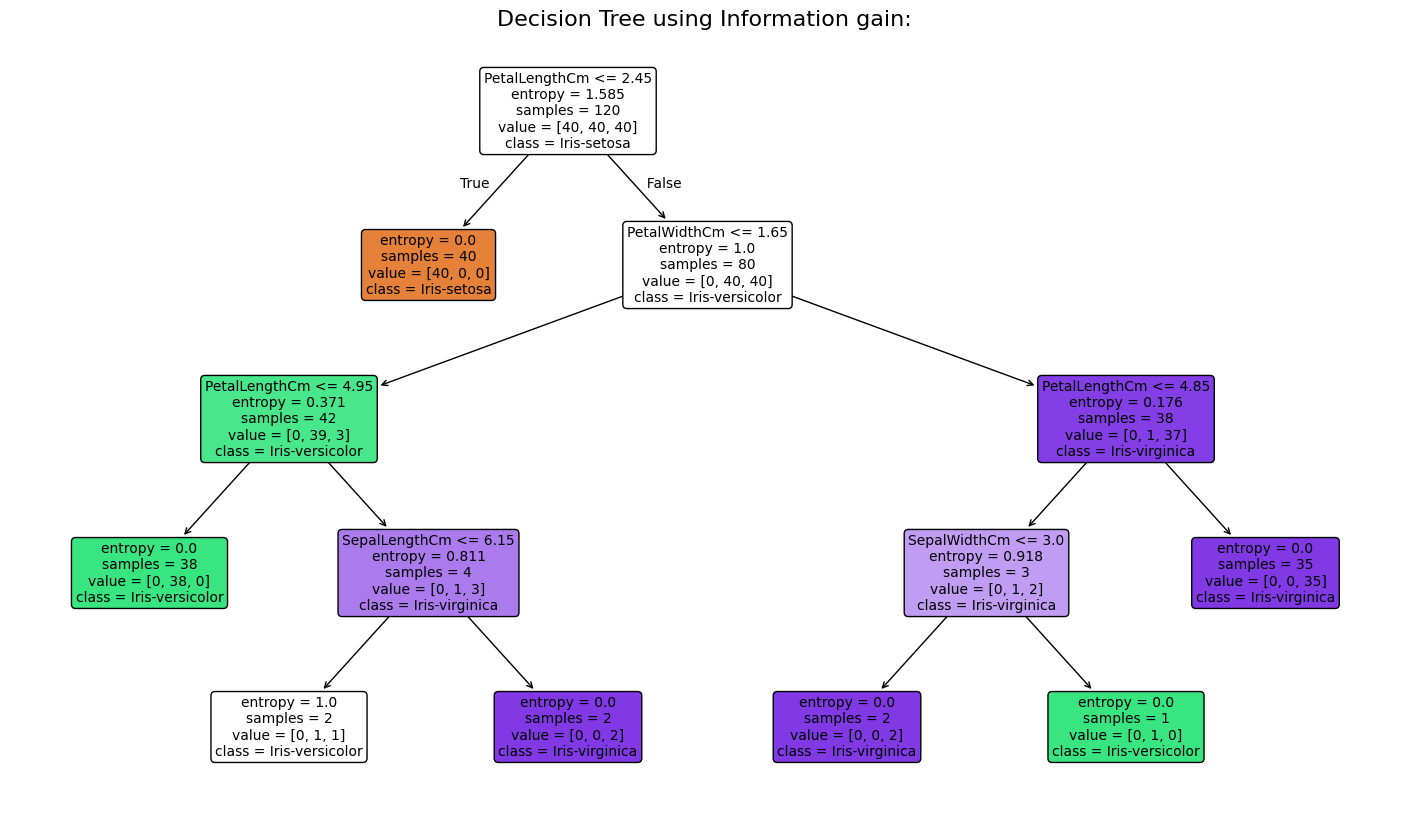

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier , plot_tree
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report)

path = "/kaggle/input/datasets/uciml/iris/Iris.csv"
df = pd.read_csv(path)

print("=" * 60)
print("IRIS DATASET")
print("=" * 60)
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\Dataset Information:")
print(df.info())

print("\Statistical Description:")
print(df.describe())

print("\Class Distribution:")
print(df["Species"].value_counts())

X= df[
[
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm"
]
]

y= df["Species"]

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size= 0.20, random_state = 42, stratify= y
)
print("\nTraining Samples:", X_train.shape[0])
print("\Testing Samples:", X_test.shape[0])

model = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state= 42)

model.fit(X_train, y_train)
print("\nDecision Tree Training completed")

y_pred= model.predict(X_test)
print("\nActual Classes:")
print(y_test.values) 

print("Predicted Classes: ")
print(y_pred)

accuracy = accuracy_score(y_test, y_pred)

print("\n" + '=' * 60)
print("MODEL ACCURACY")
print('='* 60)

print("Accuracy =", round(accuracy * 100, 2), '%')

print("\nCLassification Report:")
print(classification_report(
    y_test,  y_pred
))

cm= confusion_matrix(
    y_test,  y_pred
)
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(7,6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    [0,1,2], model.classes_
)
for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j,i, cm[i,j], ha= "center", va='center', fontsize= 14)
plt.colorbar()
plt.show()

print("\n" + '=' * 60)
print("FEATURE IMPORTANCE")
print("=" * 60)

for feature, importance in zip(
    X.columns, model.feature_importances_
):
    print(feature, '=', round(importance,4))

plt.figure(figsize= (9,6))

plt.bar(X.columns,
       model.feature_importances_)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance - IRIS Classification")

plt.xticks(rotation=20)
plt.grid(axis='y')
plt.show()

plt.figure(figsize=(18,10))

plot_tree(
    model,
    feature_names= X.columns,
    class_names= model.classes_,
    filled= True,
    rounded= True,
    fontsize= 10
)

plt.title("Decision Tree using Information gain: ",fontsize= 16)
plt.show()